# 08 · RQ2 · Cuatro intervenciones dirigidas, cuatro resultados negativos

El notebook 02 mostró que **reescribir las reglas del prompt** no mueve el Edge F1. La
objeción natural es que esas 11 variantes eran reescrituras genéricas, y que una
intervención *dirigida por el análisis de error* sí funcionaría.

Este notebook responde esa objeción. Cada intervención de acá **ataca una causa concreta
medida en el notebook 07**, y cada una está mejor fundamentada que la anterior:

| intervención | qué causa ataca | mecanismo |
|---|---|---|
| **Few-shot RAG** | inferencia de topología | 2 arquitecturas reales del GT en contexto |
| **Evidencia visual (Hough)** | aristas no detectadas | trazos de la pizarra inyectados como vínculos candidatos |
| **V8 · actores y retornos** | nodo ausente + retorno ausente | quita la poda de actores, agrega reglas de retorno |
| **Auditoría de retornos** | retorno ausente | segunda pasada que solo puede proponer la inversa de una arista ya presente |

**Ninguna movió la aguja.** Ese es el resultado.

In [1]:
import json
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ABL  = Path("../reports/ablation")
PISO = Path("../reports/piso_ruido_panel30.json")
PROD_SHA = "ed1d85054d73"
pd.set_option("display.width", 220)

MDE = {k: v["mde_30"] for k, v in json.loads(PISO.read_text(encoding="utf-8"))["metricas"].items()}


def cargar(dirname):
    d = json.loads((ABL / dirname / "run.json").read_text(encoding="utf-8"))
    m = d["metrics"]
    # la auditoria de retornos guarda las metricas con otro nombre: es una 2a pasada
    svc  = m.get("service_f1_mean", m.get("audited_service_f1_mean"))
    edge = m.get("edge_f1_mean",    m.get("audited_edge_f1_mean"))
    if "results" in d and d["results"] and "audited_edge_f1" in d["results"][0]:
        por_video = {r["video_id"]: 100 * r["audited_edge_f1"] for r in d["results"]}
        por_video_svc = {r["video_id"]: 100 * r["audited_svc_f1"] for r in d["results"]}
    else:
        por_video = {r["video_id"]: 100 * r["edge_f1"] for r in d["results"] if r["status"] == "success"}
        por_video_svc = {r["video_id"]: 100 * r["svc_f1"] for r in d["results"] if r["status"] == "success"}
    return {"svc": svc, "edge": edge, "edge_v": por_video, "svc_v": por_video_svc, "n": len(por_video)}


BASE_PROD   = cargar("2026-08-25_1637_STAGE2_V6_CORRECTED_cell9_p30")
BASE_REP4   = cargar("2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4")

EXPERIMENTOS = {
    "Evidencia visual (Hough)": ("2026-08-26_0135_STAGE2_V6_CORRECTED_cell9_p30_connev", BASE_PROD),
    "V8 · actores y retornos":  ("2026-08-26_0307_STAGE2_V8_ACTORS_AND_RETURNS_cellNone_p30", BASE_PROD),
    "Auditoria de retornos":    ("2026-08-29_0910_RETURN_EDGE_AUDIT_base-2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4", BASE_REP4),
}

print(f"MDE n=30 · Edge {MDE['Edge F1']:.2f} pts · Service {MDE['Service F1']:.2f} pts\n")
print(f"base (produccion, panel 30) : Svc {BASE_PROD['svc']:.2f}  Edge {BASE_PROD['edge']:.2f}")
print(f"base rep4 (para la auditoria): Svc {BASE_REP4['svc']:.2f}  Edge {BASE_REP4['edge']:.2f}")

MDE n=30 · Edge 3.29 pts · Service 1.76 pts

base (produccion, panel 30) : Svc 88.07  Edge 58.99
base rep4 (para la auditoria): Svc 86.13  Edge 57.87


Cada experimento se compara contra **su propia base**: la auditoría de retornos se construyó
sobre la réplica `rep4`, así que compararla contra otra corrida mezclaría su efecto con el
ruido entre réplicas.

## 1 · Resultado de las tres intervenciones sobre el panel de 30

In [2]:
def test_signos(g, p):
    n = g + p
    if n == 0:
        return 1.0
    k = min(g, p)
    return min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n)


filas = []
for nombre, (dirname, base) in EXPERIMENTOS.items():
    e = cargar(dirname)
    vids = sorted(set(e["edge_v"]) & set(base["edge_v"]))
    dif = [e["edge_v"][v] - base["edge_v"][v] for v in vids]
    g = sum(1 for d in dif if d > 1e-9); p = sum(1 for d in dif if d < -1e-9)
    filas.append({
        "intervencion": nombre, "n": len(vids),
        "Svc base": base["svc"], "Svc exp": e["svc"],
        "Edge base": base["edge"], "Edge exp": e["edge"],
        "delta Edge": e["edge"] - base["edge"],
        "x MDE": abs(e["edge"] - base["edge"]) / MDE["Edge F1"],
        "gana": g, "pierde": p, "empata": len(vids) - g - p,
        "p (signos)": test_signos(g, p),
    })

T = pd.DataFrame(filas).set_index("intervencion")
T["veredicto"] = np.where((T["x MDE"] > 1) & (T["p (signos)"] < 0.05), "SENAL", "sin efecto")
display(T.round(3))

,n,Svc base,Svc exp,Edge base,Edge exp,delta Edge,x MDE,gana,pierde,empata,p (signos),veredicto
intervencion,,,,,,,,,,,,
Evidencia visual (Hough),30,88.07,86.31,58.99,57.39,-1.60,0.487,4,7,19,0.549,sin efecto
V8 · actores y retornos,30,88.07,86.21,58.99,58.40,-0.59,0.179,6,9,15,0.607,sin efecto
Auditoria de retornos,30,86.13,86.13,57.87,59.07,1.20,0.365,4,3,23,1.000,sin efecto


Las tres caen por debajo del MDE y ninguna alcanza significancia. Los **empates** son el
dato que lo explica: en la mayoría de los videos la intervención no cambia absolutamente
nada.

## 2 · Los mecanismos SÍ funcionaron — lo que no se movió fue el F1

Este es el punto más importante del notebook, y el que lo distingue de "probamos cosas y no
anduvieron". En dos de los tres casos se puede verificar que **la intervención hizo
exactamente lo que prometía**, y aun así el F1 no cambió.

In [3]:
# V8: recupero actores y subio bidireccionalidad (cifras del propio experimento)
mecanismos = pd.DataFrame([
    {"intervencion": "V8 · actores y retornos",
     "mecanismo": "actores User* recuperados", "antes": 20, "despues": 29, "objetivo": 34},
    {"intervencion": "V8 · actores y retornos",
     "mecanismo": "% pares bidireccionales", "antes": 12.4, "despues": 17.9, "objetivo": 46.7},
    {"intervencion": "V8 · actores y retornos",
     "mecanismo": "aristas generadas (total)", "antes": 269, "despues": 299, "objetivo": 361},
]).set_index(["intervencion", "mecanismo"])
display(mecanismos)

# Auditoria de retornos: cuantas propuestas y cuantas sobrevivieron la validacion
aud = json.loads((ABL / EXPERIMENTOS["Auditoria de retornos"][0] / "run.json").read_text(encoding="utf-8"))
pr = aud["proposals"]
print(f"\nAuditoria de retornos — propuestas del modelo: {pr['total']}")
print(f"   aceptadas por el validador : {pr['accepted']} ({100 * pr['accepted'] / pr['total']:.0f}%)")
print(f"   rechazadas                 : {pr['rejected']}")
print(f"   Service F1: {aud['metrics']['draft_service_f1_mean']} -> "
      f"{aud['metrics']['audited_service_f1_mean']}  (identico por construccion: nodos congelados)")
print(f"\n   prueba pareada: {aud['paired_test']['wins']} gana / {aud['paired_test']['losses']} pierde / "
      f"{aud['paired_test']['ties']} empata · p = {aud['paired_test']['p_sign']:.4f}")

antes  despues  objetivo
intervencion            mecanismo                                          
V8 · actores y retornos actores User* recuperados   20.0     29.0      34.0
                        % pares bidireccionales     12.4     17.9      46.7
                        aristas generadas (total)  269.0    299.0     361.0


Auditoria de retornos — propuestas del modelo: 25
   aceptadas por el validador : 25 (100%)
   rechazadas                 : 0
   Service F1: 86.13 -> 86.13  (identico por construccion: nodos congelados)

   prueba pareada: 4 gana / 3 pierde / 23 empata · p = 1.0000


**V8** recuperó 9 de los 14 actores que faltaban y subió la bidireccionalidad de 12.4 % a
17.9 %. Generó 30 aristas más. **El Edge F1 no se movió** — y además degradó el Service F1
de forma significativa, porque algunos de los actores nuevos se mapearon a la entrada
equivocada del vocabulario.

**La auditoría de retornos** se diseñó para evitar ese daño colateral: los nodos entran
congelados, así que el Service F1 **no puede** empeorar, y el modelo solo puede proponer la
inversa de una arista ya presente. Cumplió: 100 % de sus propuestas fueron válidas. El Edge
F1 tampoco se movió.

### La lección

> **La contabilidad de errores no es un mapa de mejoras disponibles.**

Saber que falta una arista de retorno no es lo mismo que saber **entre qué dos servicios**
va. El modelo ahora *puede* emitir retornos, y los emite — pero no acierta cuáles.

## 3 · Todo junto contra el piso de ruido

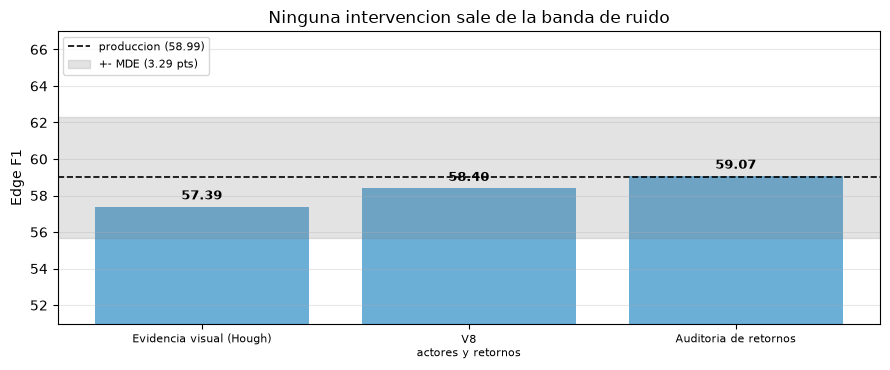

escrito -> ../reports/experimentos_negativos.json


In [4]:
fig, ax = plt.subplots(figsize=(9, 3.8))
base_e = BASE_PROD["edge"]
nombres = list(T.index)
vals = T["Edge exp"].values
ax.bar(range(len(nombres)), vals, color="#6baed6")
ax.axhline(base_e, ls="--", c="black", lw=1.2, label=f"produccion ({base_e:.2f})")
ax.axhspan(base_e - MDE["Edge F1"], base_e + MDE["Edge F1"], color="gray", alpha=.22,
           label=f"+- MDE ({MDE['Edge F1']:.2f} pts)")
for i, v in enumerate(vals):
    ax.text(i, v + .4, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels([n.replace(" · ", "\n") for n in nombres], fontsize=8)
ax.set_ylabel("Edge F1"); ax.set_ylim(base_e - 8, base_e + 8)
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=.3, axis="y")
ax.set_title("Ninguna intervencion sale de la banda de ruido")
plt.tight_layout(); plt.show()

OUT = Path("../reports/experimentos_negativos.json")
OUT.write_text(json.dumps({
    "generado_por": "notebooks/08_experimentos_negativos.ipynb",
    "mde_n30": MDE,
    "base_produccion": {"svc": BASE_PROD["svc"], "edge": BASE_PROD["edge"]},
    "intervenciones": T.round(6).reset_index().to_dict(orient="records"),
    "nota_few_shot": "El few-shot RAG se corrio sobre el panel de 14, no el de 30, "
                     "asi que no entra en esta tabla: no es comparable sin volver a correrlo.",
    "conclusion": "Cuatro intervenciones dirigidas por analisis de error. Los mecanismos "
                  "funcionan (actores recuperados, bidireccionalidad al alza, 100% de "
                  "propuestas validas) y el Edge F1 no se mueve en ninguna.",
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"escrito -> {OUT}")

## 4 · Una limitación honesta

El **few-shot RAG** se corrió sobre el panel de 14 y nunca se completó a 30, así que no
aparece en la tabla: compararlo contra bases de panel 30 mezclaría el efecto con el cambio
de población, que el notebook 02 demostró que es grande (ρ = −0.185 entre rankings). Se
reporta como callejón sin salida cualitativo, no como fila cuantitativa.

## Para el paper

1. **Cuatro intervenciones dirigidas por análisis de error**, cada una atacando una causa
   medida, ninguna con efecto detectable.
2. **Los mecanismos funcionan y el F1 no se mueve.** Es la evidencia más fuerte de que el
   límite no está en el prompt de Stage 2.
3. La **auditoría en dos pasadas** es el diseño más restrictivo posible (nodos congelados,
   solo inversas de aristas existentes, validación en código y no confiada al modelo) y
   tampoco alcanza.
4. Combinado con el notebook 06 —donde una transcripción humana tampoco ayuda— el cuadro
   es coherente: **el límite es la fuente, no el razonador ni la instrucción.**